In [39]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [62]:
URL = (
    "https://geodaten-wasser.rlp-umwelt.de/"
    "api/data/messstellen_wasserstand_abflusswerte_30"
    "?w=messstellennummer=2377050700"
)

headers = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://geodaten-wasser.rlp-umwelt.de/",
}

response = requests.get(URL, headers=headers, timeout=30)

print(response.status_code)
# print(response.text[:500])

data = response.json()

200


In [64]:
df = pd.DataFrame(data)

df = df.dropna(subset=["abfluss"])

df["datestring"] = pd.to_datetime(df["datestring"])

df["abfluss"] = (
        df["abfluss"]
        .str.replace(",", ".", regex=False)
        .pipe(pd.to_numeric)
    )

df = (
        df[["datestring", "abfluss"]]
        .rename(columns={
            "datestring": "timestamp",
            "abfluss": "discharge"
            })
        .set_index("timestamp")
        .sort_index()
    )


df

,discharge
timestamp,
2026-04-11 13:15:00+00:00,1.124
2026-04-11 13:30:00+00:00,1.124
2026-04-11 13:45:00+00:00,1.185
2026-04-11 14:00:00+00:00,1.124
2026-04-11 14:15:00+00:00,1.124
...,...
2026-05-12 11:00:00+00:00,1.006
2026-05-12 11:15:00+00:00,0.949
2026-05-12 11:30:00+00:00,1.006


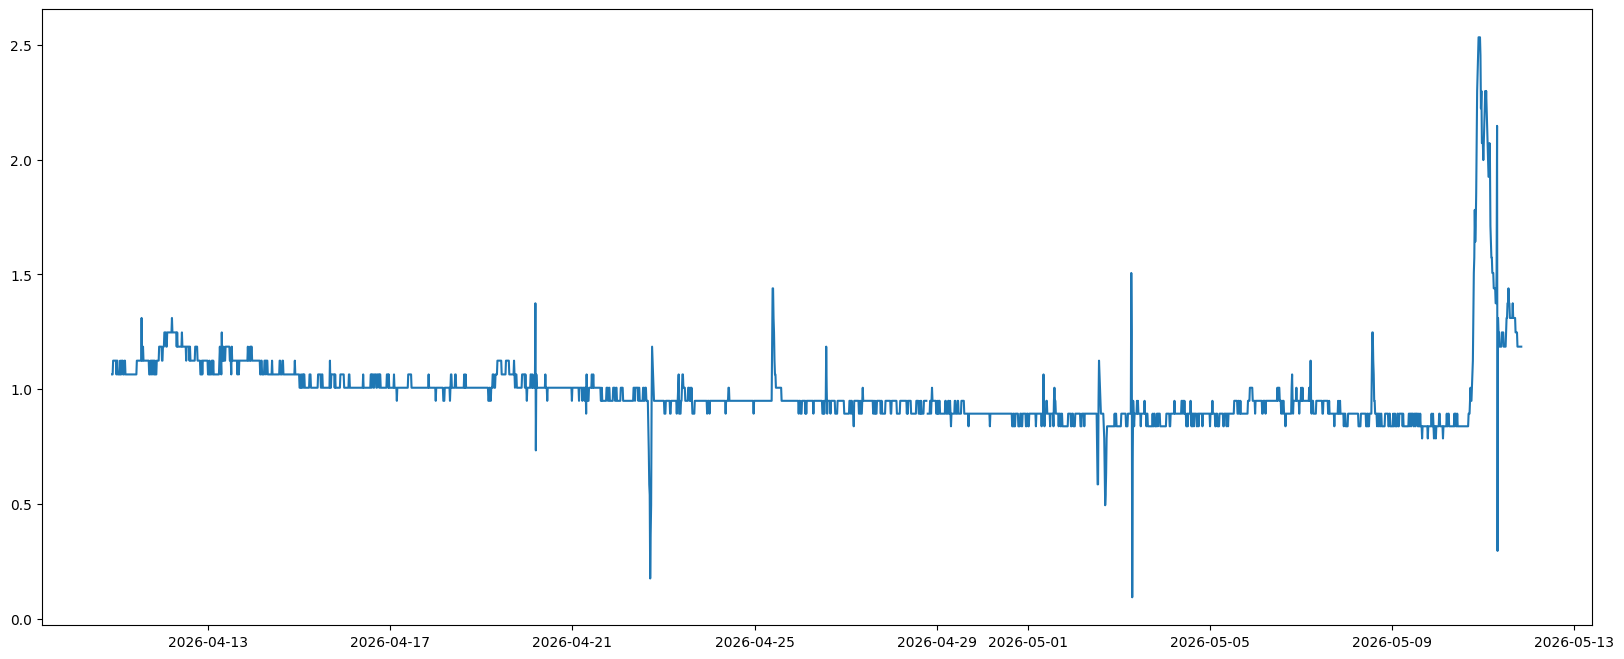

In [54]:
fig, ax = plt.subplots(figsize=(20,8))
ax.plot(df)
plt.show()


## Check bs4 Discharge scrape

In [ ]:
import requests
import pandas as pd

from bs4 import BeautifulSoup

URL = "https://www.hochwasser.rlp.de/flussgebiet/oberrhein/siebeldingen#abfluesse"


def fetch():

    response = requests.get(URL, timeout=30)
    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser",
    )

    rows = soup.select(
        ".m-detail-measurementsites__table-row__details"
    )

    data = []

    for row in rows:

        cells = row.select(
            ".m-detail-measurementsites__table-cell"
        )

        if len(cells) < 3:
            continue

        weekday = cells[0].get_text(strip=True)

        time_str = cells[1].get_text(strip=True)

        value_str = cells[2].get_text(strip=True)

        value = (
            value_str
            .replace("m³/s", "")
            .replace(",", ".")
            .strip()
        )

        data.append({
            "weekday": weekday,
            "time": time_str,
            "discharge": float(value),
        })

    df = pd.DataFrame(data)

    return df

In [30]:
HEADERS  = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0 Safari/537.36"
    ),
    "Accept": "application/json, text/plain, */*",
    "Referer": "https://geodaten-wasser.rlp-umwelt.de/",
}

In [31]:
response = requests.get(URL, headers=HEADERS, timeout=30)
response.raise_for_status()

soup = BeautifulSoup(
    response.text,
    "html.parser",
)

<!DOCTYPE html>
<html lang="de"><head><meta charset="utf-8"/><link href="/favicon.ico" rel="icon"/><link href="/apple-touch-icon-180x180.png" rel="apple-touch-icon" sizes="180x180"/><link href="/favicon-32x32.png" rel="icon" sizes="32x32" type="image/png"/><link href="/favicon-16x16.png" rel="icon" sizes="16x16" type="image/png"/><link href="/manifest.json" rel="manifest"/><meta content="width=device-width,initial-scale=1,maximum-scale=1,user-scalable=0" name="viewport"/><meta content="#000000" name="theme-color"/><meta content="Hochwasservorhersagezentrale Rheinland-Pfalz" name="description"/><meta content="Landesamt fÃ¼r Umwelt, Wasserwirtschaft und Gewerbeaufsicht Rheinland-Pfalz" name="author"/><link href="/manifest.json" rel="manifest"/><title>Hochwasservorhersagezentrale Rheinland-Pfalz</title><script>function setViewportProperty(e){var t;function n(){var n=e.clientHeight;n!==t&&requestAnimationFrame((function(){e.style.setProperty("--vh",.009999*n+"px"),t=n}))}return n(),n}windo

In [28]:
rows = soup.select(
    "MuiAccordionDetails-root"
)
rows

[]

In [21]:
df = fetch()
df

""


## Develope daily precip data

In [30]:
from tqdm import tqdm
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
from rasterio.windows import Window

import bz2
import shutil
import xarray as xr


### Scrape ICON-D2

In [227]:
import re
from tqdm import tqdm
import requests
from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urljoin

In [ ]:
url = "https://opendata.dwd.de/weather/nwp/icon-d2/grib/00/tot_prec/"
OUPUT_DIR = Path("data/forecast_precip/icon_d2/compressed")

In [230]:
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")
links = soup.find_all("a") 

In [347]:
import requests
from bs4 import BeautifulSoup
import pandas as pd


URL = "https://opendata.dwd.de/weather/nwp/icon-d2/grib/00/tot_prec/"

response = requests.get(URL)
response.raise_for_status()

soup = BeautifulSoup(response.text, "html.parser")

rows = []

for a in soup.find_all("a"):

    href = a.get("href")

    if not href:
        continue

    if "lat-lon" not in href:
        continue

    if not href.endswith(".grib2.bz2"):
        continue

    # sibling text after </a>
    tail = a.next_sibling

    if not tail:
        continue

    parts = tail.strip().split()

    upload_time = pd.to_datetime(
        f"{parts[0]} {parts[1]}",
        # format="%d-%b-%Y %H:%M:%S"
    )

    rows.append({
        "filename": href,
        "datetime_upload": upload_time,
    })


df = pd.DataFrame(rows)

df.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_29996\2230458718.py:36: UserWarning: Parsing dates in %d-May-%Y %H:%m:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  upload_time = pd.to_datetime(


,filename,datetime_upload
0,icon-d2_germany_regular-lat-lon_single-level_2...,2026-05-16 00:44:21
1,icon-d2_germany_regular-lat-lon_single-level_2...,2026-05-16 00:48:01
2,icon-d2_germany_regular-lat-lon_single-level_2...,2026-05-16 00:48:37
3,icon-d2_germany_regular-lat-lon_single-level_2...,2026-05-16 00:49:27
4,icon-d2_germany_regular-lat-lon_single-level_2...,2026-05-16 00:50:03


In [ ]:
DOWNLOAD_DIR = Path("data/raw/icon")

existing_files = {
    p.name
    for p in DOWNLOAD_DIR.glob("*.bz2")
}

missing_df = df[
    ~df["filename"].isin(existing_files)
]

In [69]:
root = Path("data/forecast_precip")
compressed_dir = root / "icon_d2"

COMPRESSED_PATH = [p for p in compressed_dir.glob("*.grib2.bz2") if "icosahedral" not in str(p)][-1]
GRIB_PATH = [p for p in compressed_dir.glob("*.grib2") if "icosahedral" not in str(p)][-1]
CATCHMENT_PATH = root / "catchment" / "catchment_queich_siebeldingen.gpkg"

In [64]:
def decompress_bz2(
    source_path: str | Path,
    target_path: str | Path | None = None,
) -> Path:
    source_path = Path(source_path)

    if target_path is None:
        target_path = source_path.with_suffix("")

    target_path = Path(target_path)

    with bz2.open(source_path, "rb") as source:
        with open(target_path, "wb") as target:
            shutil.copyfileobj(source, target)

    return target_path


grib_path = decompress_bz2(
    COMPRESSED_PATH
)

print(grib_path)

data\forecast_precip\icon_d2\icon-d2_germany_regular-lat-lon_single-level_2026051600_000_2d_tot_prec.grib2


In [65]:
catchment = gpd.read_file(CATCHMENT_PATH)
print(catchment.crs)

EPSG:3044


In [190]:
ds.valid_time.values

array(['2026-05-16T00:00:00.000000000', '2026-05-16T00:15:00.000000000',
       '2026-05-16T00:30:00.000000000', '2026-05-16T00:45:00.000000000'],
      dtype='datetime64[ns]')

In [109]:
ds = xr.open_dataset(GRIB_PATH, engine="cfgrib")

if "tp" in ds:
    precip = ds["tp"]
    
precip = precip.rename(
    {
        "latitude": "y",
        "longitude": "x",
    }
)

# CRS
precip = precip.rio.write_crs("EPSG: 4326")
catchment = catchment.to_crs(precip.rio.crs)

print(precip.rio.crs)
print(catchment.crs)

EPSG:4326
GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [107]:
minx, miny, maxx, maxy = catchment.total_bounds

precip_cropped = precip.rio.clip_box(
    minx=minx,
    miny=miny,
    maxx=maxx,
    maxy=maxy,
)

In [ ]:
# precip_masked = precip_cropped.rio.clip(
#     catchment.geometry,
#     catchment.crs,
#     drop=False,
# )

# # precip_masked.to_netcdf(OUTPUT_PATH)

In [122]:
precip_cropped

<xarray.DataArray 'tp' (step: 4, y: 9, x: 13)> Size: 2kB
[468 values with dtype=float32]
Coordinates:
    time         datetime64[ns] 8B ...
  * step         (step) timedelta64[ns] 32B 00:00:00 00:15:00 00:30:00 00:45:00
    surface      float64 8B ...
  * y            (y) float64 72B 49.16 49.18 49.2 49.22 ... 49.28 49.3 49.32
  * x            (x) float64 104B 7.82 7.84 7.86 7.88 7.9 ... 8.0 8.02 8.04 8.06
    valid_time   (step) datetime64[ns] 32B ...
    spatial_ref  int64 8B 0
Attributes: (12/30)
    GRIB_paramId:                             228228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      906390
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_name:                                Total Precipitation
    GRIB_shortName:                           tp
    GRIB_units:                               kg m**-2
    long_name:                                Total Precipitation
    units:                                    kg m**-2
    standard_name:                            unknown

In [147]:
sample = precip_cropped.isel(step=0)
sample.time.values

np.datetime64('2026-05-16T00:00:00.000000000')

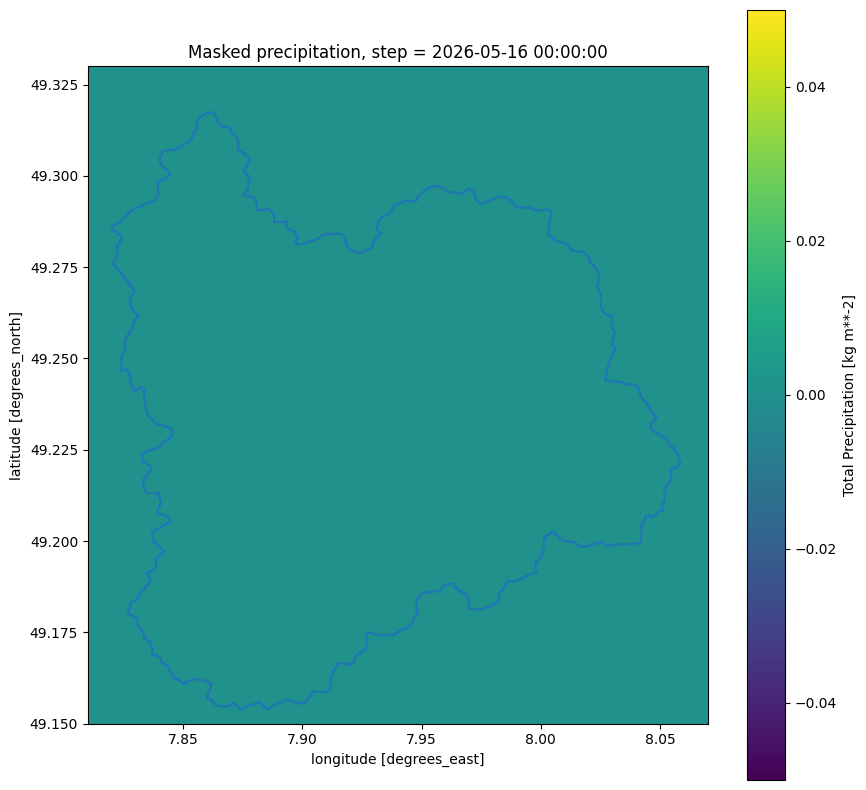

In [149]:
# Select one timestep
step = 1
sample = precip_cropped.isel(step=step)
# sample = precip_masked.isel(step=0)

fig, ax = plt.subplots(figsize=(10, 10))

# Plot precipitation raster
sample.plot(ax=ax)

# Overlay watershed border
catchment.boundary.plot(
    ax=ax,
)

plt.title(f"Masked precipitation, step = {pd.to_datetime(sample.time.values)}")
plt.show()